# Capstone Project - GNN for PPI Tissue Prediction

I am trying to replicate the OhmNet paper but using a Graph Attention Network (GAT) instead of just regular Node2Vec or whatever. It's been really hard to figure out how to handle all these different tissues.

In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch_geometric
from torch_geometric.nn import GATConv
from torch_geometric.data import Data, Batch
from torch_geometric.loader import DataLoader, LinkNeighborLoader
import pandas as pd
import numpy as np
import networkx as nx
import os
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score
import gc

# Checking if the GPU is active because otherwise it takes forever
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"I am using: {device}")

# I need to tell the script where to find the data files
data_dir = Path('./data')

I am using: cuda


### EDA - Initial File Investigation
I had to look at the folder `data` because I forgot what files were in there and how big they were! I need to know what to do with each one.

In [37]:
print("Looking at the data files...")
import os
files = os.listdir(data_dir)
for f in files:
    size = os.path.getsize(data_dir / f) / (1024*1024)
    print(f"- {f} ({size:.2f} MB)")

# What I need to do:
# Visualized the data using basic txt file explorers and saw a couple of things of interest:
    # - BrendaTissue.obo: This is like a dictionary. I'll read it to map names like 'brain' to IDs like 'BTO:0000142'.
    # - tissue.hierarchy: This has parent-child pairs. I'll build a graph with it for Node2Vec and the custom loss.
    # - PPT-Ohmnet_tissues-combined.edgelist: The main data! 3.6M lines of PPIs. I have to group them by pair then collapse them into a pair-tissues multi-hot vectors

Looking at the data files...
- BrendaTissue.obo (1.74 MB)
- PPT-Ohmnet_tissues-combined.edgelist (78.07 MB)
- tissue.edges (0.01 MB)
- tissue.hierarchy (0.01 MB)


### Loading Data
I have to load the tissue hierarchy. I struggled a lot here because I didn't realize it was a directed graph and kept getting the indices mixed up.

In [39]:
# Load the tissue hierarchy stuff
tissue_hierarchy_path = data_dir / 'tissue.hierarchy'
G_tissue = nx.read_edgelist(str(tissue_hierarchy_path), create_using=nx.DiGraph())

print(f"The tissue graph has {G_tissue.number_of_nodes()} nodes.")

# I needed to sort these because I want the indices to be consistent
tissue_nodes = sorted(list(G_tissue.nodes()))
tissue_to_idx = {node: i for i, node in enumerate(tissue_nodes)}

# Making the edge index for the tissue hierarchy
edges_tissue = []
for u, v in G_tissue.edges():
    edges_tissue.append([tissue_to_idx[u], tissue_to_idx[v]])

# This part was tricky had to read the documentation for shape. I had to transpose it or PyG throws an error.
edges_index_tissue = torch.tensor(edges_tissue, dtype=torch.long).t().contiguous()

print(f"Tissue edge index shape processed: {edges_index_tissue.shape} ") # As per documentation shape has to be ([2, num_edges])

The tissue graph has 219 nodes.
Tissue edge index shape processed: torch.Size([2, 218]) 


### Mapping Tissues to BTO IDs
I found out that the PPI file uses names like 'brain' but my hierarchy uses BTO IDs like 'BTO:0000142'. This was such a pain. I had to load this BrendaTissue.obo file and match them up manually. I even had to make a 'manual rescue' for stuff that just wouldn't match!

In [ ]:
print("Building mapping from BrendaTissue.obo...")
obo_path = data_dir / 'BrendaTissue.obo'
name_to_bto = {}
with open(obo_path, 'r', encoding='utf-8') as f:
    curr_id = None
    for line in f:
        line = line.strip()
        if line.startswith('id: '):
            curr_id = line[4:]
        elif line.startswith('name: ') and curr_id:
            name_to_bto[line[6:].lower()] = curr_id

# I copied this manual rescue because some tissues are just named inconsistently in the data
manual_rescue = {
    'culture condition cd8 cell': 'BTO:0004410',
    'b lymphocyte': 'BTO:0000776',
    'b lymphocytes': 'BTO:0000776', 
    't lymphocyte': 'BTO:0000782', 
    't lymphocytes': 'BTO:0000782'  
}

def get_tissue_idx(t_name):
    # The PPI file uses underscores but names in OBO usually have spaces
    normalized = str(t_name).lower().replace('_', ' ')
    if normalized in manual_rescue:
        bto_id = manual_rescue[normalized]
    else:
        bto_id = name_to_bto.get(normalized)
        
    if not bto_id:
        return None
    
    if bto_id in tissue_to_idx:
        return tissue_to_idx[bto_id]
    if bto_id + '_NODE' in tissue_to_idx:
        return tissue_to_idx[bto_id + '_NODE']
    return None

print(f"Loaded {len(name_to_bto)} names and manual rescues for mapping.")

Building mapping from BrendaTissue.obo...
Loaded 5903 names and manual rescues for mapping.


### Preprocessing PPI Data
Now I have to load the actual protein-protein interactions. This file is huge and cleaning it was a nightmare. I have to map the tissues properly now or the labels will be all zeros!

In [19]:
# Load the big PPI file
ppi_file = data_dir / 'PPT-Ohmnet_tissues-combined.edgelist'
df = pd.read_csv(ppi_file, sep='\t')
df.columns = ['protein_a', 'protein_b', 'tissue']
original_count = len(df)

print("Applying tissue mapping...")
df['t_idx'] = df['tissue'].apply(get_tissue_idx)
df = df.dropna(subset=['t_idx'])
mapped_count = len(df)

print(f"Mapped {mapped_count}/{original_count} PPI records successfully!")

# Getting all unique proteins.
all_proteins = pd.concat([df['protein_a'], df['protein_b']]).unique()
protein_to_idx = {prot: i for i, prot in enumerate(all_proteins)}
num_unique_proteins = len(all_proteins)

print(f"Found {num_unique_proteins} unique proteins.")

Applying tissue mapping...
Mapped 3666563/3666563 PPI records successfully!
Found 4510 unique proteins.


### Handling Labels (Tissues)
Each interaction happens in certain tissues. I need to make a vector where it's 1 if the interaction happens there. This part was really confusing because I have to group by (protein_a, protein_b) and combine the tissues.

In [20]:
# Grouping by interaction to see which tissues they are in
# I'm doing this the slow way because I'm still learning Pandas loops
interaction_groups = df.groupby(['protein_a', 'protein_b'])

num_tissues = len(tissue_nodes)
num_interactions = len(interaction_groups)

labels_matrix = np.zeros((num_interactions, num_tissues))
edge_list_all = []

for i, ((p1, p2), group) in enumerate(interaction_groups):
    u = protein_to_idx[p1]
    v = protein_to_idx[p2]
    edge_list_all.append([u, v])
    
    # Collect all tissues for this pair
    tissues_present_indices = group['t_idx'].unique()
    for tidx in tissues_present_indices:
        labels_matrix[i, int(tidx)] = 1.0

edge_label_index_all = torch.tensor(edge_list_all, dtype=torch.long).t().contiguous()
edge_label_all = torch.tensor(labels_matrix, dtype=torch.float)

print("Grouped unique interactions:", num_interactions)
print("Final Label Matrix Shape:", edge_label_all.shape)

# I need to find the leaf nodes for the final score
leaf_node_indices = [i for i, node in enumerate(tissue_nodes) if G_tissue.in_degree(node) == 0 and node != 'Root_NODE']
print(f"Found {len(leaf_node_indices)} leaf tissues.")

Grouped unique interactions: 70338
Final Label Matrix Shape: torch.Size([70338, 219])
Found 107 leaf tissues.


### EDA - Visualizing our Labels
Now that I have the labels grouped, I can finally see what the data distribution looks like. I'm afraid some tissues are barely there!

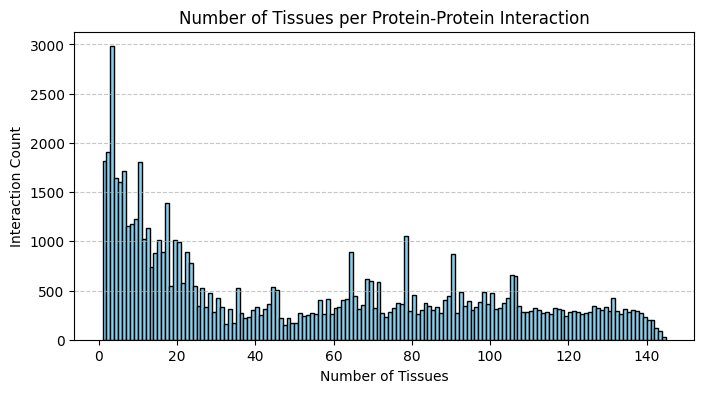

Average tissues per interaction: 52.13


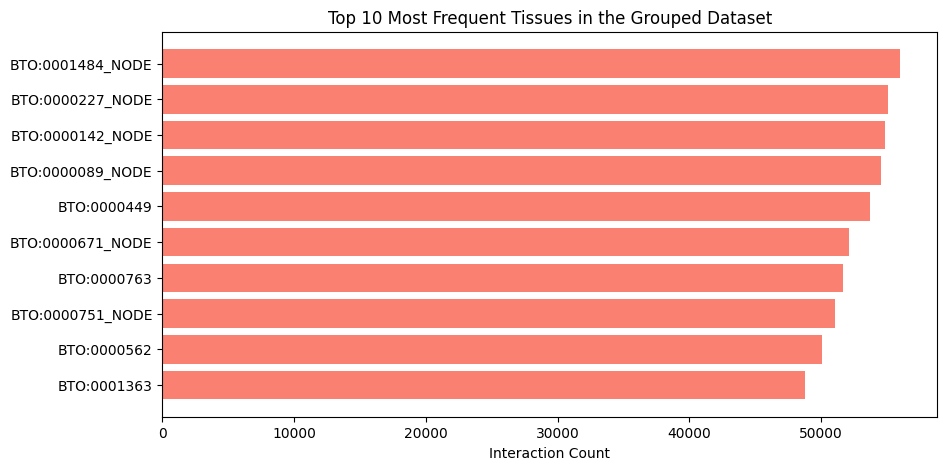

In [36]:
# EDA Graph 1: How many tissues per interaction?
plt.figure(figsize=(8, 4))
tissues_per_ppi = edge_label_all.sum(dim=1).numpy()
plt.hist(tissues_per_ppi, bins=range(1, int(tissues_per_ppi.max()) + 2), color='skyblue', edgecolor='black')
plt.title("Number of Tissues per Protein-Protein Interaction")
plt.xlabel("Number of Tissues")
plt.ylabel("Interaction Count")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print(f"Average tissues per interaction: {tissues_per_ppi.mean():.2f}")

# EDA Graph 2: Top 10 Most Common Tissues?
plt.figure(figsize=(10, 5))
tissue_counts = edge_label_all.sum(dim=0).numpy()
top_indices = np.argsort(tissue_counts)[-10:]
plt.barh([tissue_nodes[i] for i in top_indices], tissue_counts[top_indices], color='salmon')
plt.title("Top 10 Most Frequent Tissues in the Grouped Dataset")
plt.xlabel("Interaction Count")
plt.show()

### Splitting the data
I need to divide this into train, validation, and test. The expert said to do an 80/20 split then split the 80% again to get the 72/8/20 ratio.

In [22]:
from sklearn.model_selection import train_test_split

indices = np.arange(num_interactions)
# First split: 20% for testing
train_val_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42, shuffle=True)
# Second split: 10% of the remaining for validation (which is 8% of total)
train_idx, val_idx = train_test_split(train_val_idx, test_size=0.1, random_state=42)

print(f"Train size: {len(train_idx)}, Val size: {len(val_idx)}, Test size: {len(test_idx)}")

full_graph_data = Data(x=torch.arange(num_unique_proteins), edge_index=edge_label_index_all)

batch_size = 1024 # Increased this so it trains faster

train_loader = LinkNeighborLoader(
    full_graph_data,
    num_neighbors=[15, 10],
    batch_size=batch_size,
    edge_label_index=edge_label_index_all[:, train_idx],
    edge_label=edge_label_all[train_idx],
    shuffle=True
)

val_loader = LinkNeighborLoader(
    full_graph_data,
    num_neighbors=[15, 10],
    batch_size=batch_size,
    edge_label_index=edge_label_index_all[:, val_idx],
    edge_label=edge_label_all[val_idx],
    shuffle=False
)

test_loader = LinkNeighborLoader(
    full_graph_data,
    num_neighbors=[15, 10],
    batch_size=batch_size,
    edge_label_index=edge_label_index_all[:, test_idx],
    edge_label=edge_label_all[test_idx],
    shuffle=False
)

Train size: 50643, Val size: 5627, Test size: 14068


### Tissue Embeddings (Node2Vec)
Using Node2Vec to get features for the tissues. 1000 epochs just like the big notebook.

In [23]:
from torch_geometric.nn import Node2Vec

tissue_n2v_model = Node2Vec(edges_index_tissue, embedding_dim=64, walk_length=20, 
                            context_size=10, walks_per_node=10, num_negative_samples=1, 
                            sparse=True).to(device)

torch.nn.init.xavier_uniform_(tissue_n2v_model.embedding.weight)

n2v_loader = tissue_n2v_model.loader(batch_size=128, shuffle=True, num_workers=0)
n2v_optimizer = torch.optim.SparseAdam(list(tissue_n2v_model.parameters()), lr=0.01)

tissue_n2v_model.train()
for epoch in range(1, 1001):
    total_loss = 0
    for pos_rw, neg_rw in n2v_loader:
        n2v_optimizer.zero_grad()
        loss = tissue_n2v_model.loss(pos_rw.to(device), neg_rw.to(device))
        loss.backward()
        n2v_optimizer.step()
        total_loss += loss.item()
    if epoch % 100 == 0:
        print(f"Node2Vec Epoch {epoch}, Loss: {total_loss/len(n2v_loader):.4f}")

global_tissue_address = tissue_n2v_model().detach()
print("Tissue embeddings ready.")

Node2Vec Epoch 100, Loss: 0.7824
Node2Vec Epoch 200, Loss: 0.7703
Node2Vec Epoch 300, Loss: 0.7668
Node2Vec Epoch 400, Loss: 0.7620
Node2Vec Epoch 500, Loss: 0.7572
Node2Vec Epoch 600, Loss: 0.7554
Node2Vec Epoch 700, Loss: 0.7517
Node2Vec Epoch 800, Loss: 0.7489
Node2Vec Epoch 900, Loss: 0.7515
Node2Vec Epoch 1000, Loss: 0.7465
Tissue embeddings ready.


### Defining the Model
Late Fusion GAT model.

In [24]:
class LateFusionGAT(nn.Module):
    def __init__(self, num_proteins, protein_embedding_dim, num_heads, gat_hidden_channels, 
                 gat_output_channels, tissue_address_dim, mlp_hidden_channels, 
                 num_tissues, global_tissue_address_tensor, dropout_rate=0.2):
        super().__init__()
        self.num_tissues = num_tissues
        self.global_tissue_address = nn.Parameter(global_tissue_address_tensor, requires_grad=False)
        self.protein_embedding = nn.Embedding(num_proteins, protein_embedding_dim)
        
        self.gat1 = GATConv(protein_embedding_dim, gat_hidden_channels, heads=num_heads, dropout=dropout_rate)
        self.gat2 = GATConv(gat_hidden_channels * num_heads, gat_output_channels, heads=1, concat=False, dropout=dropout_rate)
        
        combined_dim = gat_output_channels * 2 + tissue_address_dim
        self.mlp = nn.Sequential(
            nn.Linear(combined_dim, mlp_hidden_channels),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(mlp_hidden_channels, 1)
        )

    def forward(self, batch):
        x = self.protein_embedding(batch.x.to(device))
        x = F.elu(self.gat1(x, batch.edge_index.to(device)))
        x = self.gat2(x, batch.edge_index.to(device))
        
        u_idx, v_idx = batch.edge_label_index[0], batch.edge_label_index[1]
        u_feat, v_feat = x[u_idx], x[v_idx]
        
        # Making it easier to read by splitting the expansion steps
        batch_size = u_feat.size(0)
        u_feat_expanded = u_feat.unsqueeze(1).repeat(1, self.num_tissues, 1)
        v_feat_expanded = v_feat.unsqueeze(1).repeat(1, self.num_tissues, 1)
        tissue_feat = self.global_tissue_address.unsqueeze(0).repeat(batch_size, 1, 1)
        
        combined = torch.cat([u_feat_expanded, v_feat_expanded, tissue_feat], dim=-1)
        out = self.mlp(combined).squeeze(-1)
        return torch.sigmoid(out)

### Custom Loss Function
Adding a penalty for hierarchy violations.

In [25]:
hierarchical_pairs = edges_index_tissue.t()

def custom_loss(predictions, targets, hierarchy_edges, lambda_penalty=0.1):
    bce = F.binary_cross_entropy(predictions, targets)
    child_idx, parent_idx = hierarchy_edges[:, 0], hierarchy_edges[:, 1]
    
    # Predictions for children should be <= predictions for parents
    diff = predictions[:, child_idx] - predictions[:, parent_idx]
    penalty = torch.mean(torch.clamp(diff, min=0)**2)
    return bce + lambda_penalty * penalty

### THE TRAINING LOOP
Model structural hyperparameters and model instantiation separated from the training loop to load the model later.

In [ ]:
# These are the 'pro' parameters I copied
protein_embedding_dim = 256
num_heads = 16
gat_hidden_channels = 256
gat_output_channels = 256
tissue_address_dim = global_tissue_address.shape[1]
mlp_hidden_channels = 1024
dropout_rate = 0.3

model = LateFusionGAT(
    num_proteins=num_unique_proteins, protein_embedding_dim=protein_embedding_dim,
    num_heads=num_heads, gat_hidden_channels=gat_hidden_channels,
    gat_output_channels=gat_output_channels, tissue_address_dim=tissue_address_dim,
    mlp_hidden_channels=mlp_hidden_channels, num_tissues=num_tissues,
    global_tissue_address_tensor=global_tissue_address, dropout_rate=dropout_rate
).to(device)

Training with early stopping.

In [26]:
# These are the 'pro' parameters I copied
protein_embedding_dim = 256
num_heads = 16
gat_hidden_channels = 256
gat_output_channels = 256
tissue_address_dim = global_tissue_address.shape[1]
mlp_hidden_channels = 1024
dropout_rate = 0.3

model = LateFusionGAT(
    num_proteins=num_unique_proteins, protein_embedding_dim=protein_embedding_dim,
    num_heads=num_heads, gat_hidden_channels=gat_hidden_channels,
    gat_output_channels=gat_output_channels, tissue_address_dim=tissue_address_dim,
    mlp_hidden_channels=mlp_hidden_channels, num_tissues=num_tissues,
    global_tissue_address_tensor=global_tissue_address, dropout_rate=dropout_rate
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
num_epochs = 1000
patience = 50
best_val_loss = float('inf')
epochs_no_improve = 0
history = {'train': [], 'val': []}

for epoch in range(num_epochs):
    model.train()
    total_train_loss = 0
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        preds = model(batch)
        loss = custom_loss(preds, batch.edge_label, hierarchical_pairs.to(device))
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()
        
    avg_train_loss = total_train_loss / len(train_loader)
    history['train'].append(avg_train_loss)
    
    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            preds = model(batch)
            loss = custom_loss(preds, batch.edge_label, hierarchical_pairs.to(device))
            total_val_loss += loss.item()
    
    avg_val_loss = total_val_loss / len(val_loader)
    history['val'].append(avg_val_loss)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}, Train: {avg_train_loss:.4f}, Val: {avg_val_loss:.4f}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), 'best_model.pt')
    else:
        epochs_no_improve += 1
    
    if epochs_no_improve >= patience:
        print(f"Early stopping at {epoch+1}!")
        break

Epoch 10, Train: 0.3471, Val: 0.3319
Epoch 20, Train: 0.2845, Val: 0.2599
Epoch 30, Train: 0.2580, Val: 0.2326
Epoch 40, Train: 0.2434, Val: 0.2206
Epoch 50, Train: 0.2340, Val: 0.2136
Epoch 60, Train: 0.2267, Val: 0.2050
Epoch 70, Train: 0.2196, Val: 0.1990
Epoch 80, Train: 0.2148, Val: 0.1920
Epoch 90, Train: 0.2111, Val: 0.1863
Epoch 100, Train: 0.2068, Val: 0.1844
Epoch 110, Train: 0.2052, Val: 0.1833
Epoch 120, Train: 0.2008, Val: 0.1794
Epoch 130, Train: 0.1990, Val: 0.1749
Epoch 140, Train: 0.1963, Val: 0.1736
Epoch 150, Train: 0.1947, Val: 0.1691
Epoch 160, Train: 0.1920, Val: 0.1672
Epoch 170, Train: 0.1899, Val: 0.1658
Epoch 180, Train: 0.1897, Val: 0.1665
Epoch 190, Train: 0.1856, Val: 0.1641
Epoch 200, Train: 0.1845, Val: 0.1585
Epoch 210, Train: 0.1830, Val: 0.1604
Epoch 220, Train: 0.1816, Val: 0.1563
Epoch 230, Train: 0.1797, Val: 0.1545
Epoch 240, Train: 0.1791, Val: 0.1542
Epoch 250, Train: 0.1770, Val: 0.1529
Epoch 260, Train: 0.1754, Val: 0.1510
Epoch 270, Train: 0.1

### PLotting loss curves

If the orange line starts going up while the blue stays down, it's overfitting!


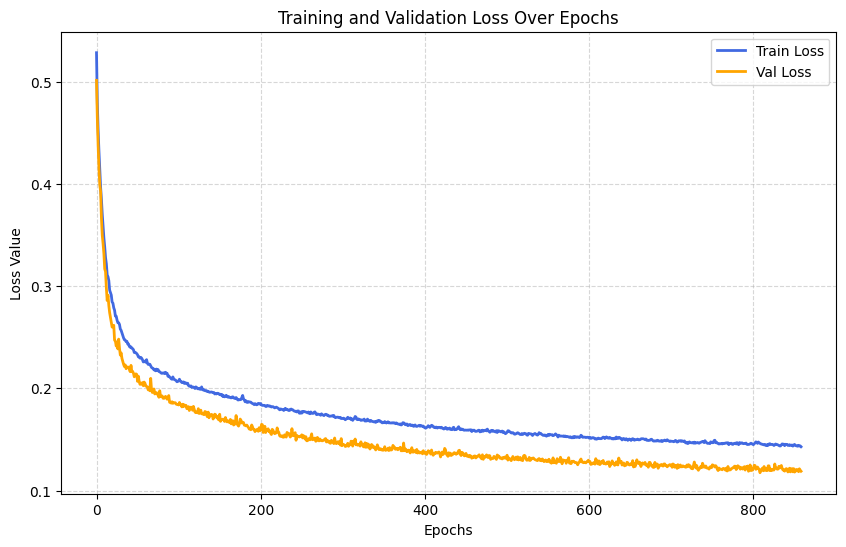

In [30]:
# I wanted to see if the model was actually learning or just oscillating
plt.figure(figsize=(10, 6))
plt.plot(history['train'], label='Train Loss', color='royalblue', linewidth=2)
plt.plot(history['val'], label='Val Loss', color='orange', linewidth=2)

plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss Value')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# Adding a note to remind myself what to look for
print("If the orange line starts going up while the blue stays down, it's overfitting!")
plt.show()


### Load model

In [ ]:
# I saved the weights during training whenever the validation loss got better.
# Now I'm loading them back so I can test the 'best' version of the model.
model_path = 'best_model.pt'

if os.path.exists(model_path):
    print(f"Loading weights from {model_path}...")
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval() # Setting to eval mode so dropout doesn't mess with my predictions
    print("Model loaded and ready for testing!")
else:
    print(f"Error: Could not find {model_path}. Did the training finish?")


### Testing Results

In [ ]:
from sklearn.metrics import average_precision_score, f1_score

model.eval()
all_preds, all_labels = [], []
leaf_auprc = []
leaf_f1_scores = []

threshold = 0.5

print(f"Calculating metrics for {len(leaf_node_indices)} leaf tissues...")

with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        preds = model(batch)
        all_preds.append(preds.cpu())
        all_labels.append(batch.edge_label.cpu())

all_preds = torch.cat(all_preds, dim=0).numpy()
all_labels = torch.cat(all_labels, dim=0).numpy()

leaf_auroc = []
for j in leaf_node_indices:
    if all_labels[:, j].sum() > 0 and (1.0 - all_labels[:, j]).sum() > 0:
        leaf_auroc.append(roc_auc_score(all_labels[:, j], all_preds[:, j]))


for j in leaf_node_indices:
    # Get the true labels and my model's predictions for this specific tissue
    y_true = all_labels[:, j]
    y_pred = all_preds[:, j]
    
    # I can only calculate scores if there is at least one '1' and one '0' in the test set
    if y_true.sum() > 0 and (1.0 - y_true).sum() > 0:
        # AUPRC (Average Precision)
        auprc = average_precision_score(y_true, y_pred)
        leaf_auprc.append(auprc)
        
        # F1 Score (requires turning probabilities into 0 or 1)
        y_pred_binary = (y_pred >= threshold).astype(int)
        f1 = f1_score(y_true, y_pred_binary, zero_division=0)
        leaf_f1_scores.append(f1)
        
# Now I average them to get the 'Macro' results
print(f"--- Leaf Tissue Results ---")
print(f"Test Leaf AUROC: {np.mean(leaf_auroc):.4f}")
print(f"Macro-AUPRC: {np.mean(leaf_auprc):.4f}")
print(f"Macro-F1 Score: {np.mean(leaf_f1_scores):.4f}")
print(f"(Based on {len(leaf_auprc)} tissues that had valid test data)")

Calculating metrics for 107 leaf tissues...
--- Leaf Tissue Results ---
Test Leaf AUROC: 0.9702
Macro-AUPRC: 0.8762
Macro-F1 Score: 0.8092
(Based on 107 tissues that had valid test data)


### Attention weights

In [ ]:
# Identify the hub protein
target_prot = df['protein_a'].value_counts().idxmax()
target_idx = protein_to_idx[target_prot]

# Get a list of all protein names based on their indices
idx_to_protein = {v: k for k, v in protein_to_idx.items()}

model.eval()
with torch.no_grad():
    # 1. Get embeddings and attention weights from the first GAT layer
    x_emb = model.protein_embedding(full_graph_data.x.to(device))
    _, (edge_idx, alpha) = model.gat1(x_emb, full_graph_data.edge_index.to(device), return_attention_weights=True)
    
    # 2. Average weights across all heads and move to CPU
    alpha = alpha.mean(dim=-1).cpu().numpy()
    edge_idx = edge_idx.cpu().numpy()
    
    # 3. Filter for edges connected to our target protein
    mask = (edge_idx[0] == target_idx)
    neighbor_indices = edge_idx[1, mask]
    neighbor_weights = alpha[mask]
    
    # 4. Sort neighbors by attention weight (highest first)
    sorted_indices = np.argsort(neighbor_weights)[::-1]
    
    print(f"Top 10 Attention Weights for Protein: {target_prot}")
    print("-" * 45)
    print(f"{'Neighbor Protein':<20} | {'Attention Weight':<15}")
    print("-" * 45)
    
    for i in range(min(10, len(sorted_indices))):
        idx = sorted_indices[i]
        neighbor_name = idx_to_protein[neighbor_indices[idx]]
        weight = neighbor_weights[idx]
        print(f"{neighbor_name:<20} | {weight:.4f}")


Top 10 Attention Weights for Protein: 1956
---------------------------------------------
Neighbor Protein     | Attention Weight
---------------------------------------------
4257                 | 0.4562
1299                 | 0.3174
26270                | 0.2862
3226                 | 0.2840
6523                 | 0.2732
10439                | 0.2658
1490                 | 0.2424
7389                 | 0.2160
1174                 | 0.2003
3371                 | 0.1997


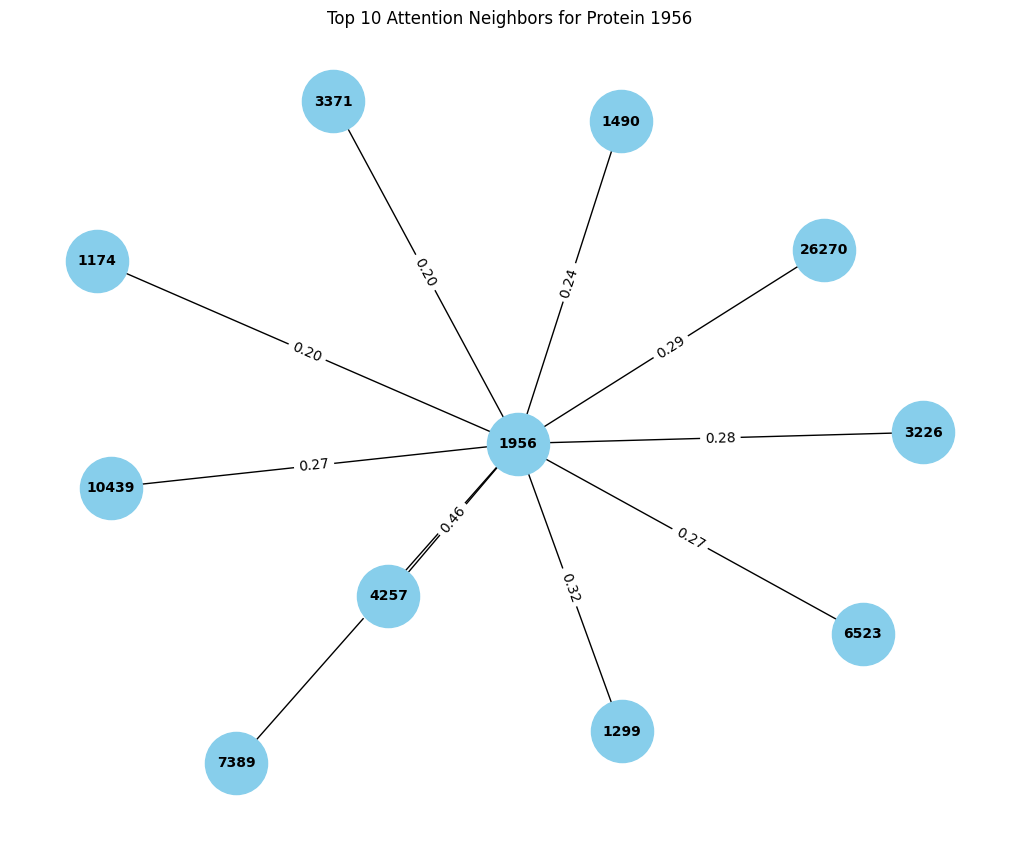

In [35]:
def simple_plot_attn(target_prot):
    target_idx = protein_to_idx[target_prot]
    
    # Map index back to name for graph labels
    idx_to_protein = {v: k for k, v in protein_to_idx.items()}
    
    model.eval()
    with torch.no_grad():
        x_emb = model.protein_embedding(full_graph_data.x.to(device))
        _, (edge_idx, alpha) = model.gat1(x_emb, full_graph_data.edge_index.to(device), return_attention_weights=True)
        
        alpha = alpha.mean(dim=-1).cpu().numpy()
        edge_idx = edge_idx.cpu().numpy()
        
        # Filter for neighbors where our protein is the source (edge_idx[0])
        mask = (edge_idx[0] == target_idx)
        sub_edges = edge_idx[:, mask]
        sub_alpha = alpha[mask]
        
        # --- NEW: Sort by attention weight descending ---
        sort_idx = np.argsort(sub_alpha)[::-1]
        top_idx = sort_idx[:10]  # Take the top 10
        
        G = nx.Graph()
        for i in top_idx:
            u_name = idx_to_protein[sub_edges[0, i]]
            v_name = idx_to_protein[sub_edges[1, i]]
            G.add_edge(u_name, v_name, weight=sub_alpha[i])
            
        plt.figure(figsize=(10, 8))
        pos = nx.spring_layout(G)
        nx.draw(G, pos, with_labels=True, node_size=2000, node_color='skyblue', font_size=10, font_weight='bold')
        
        # Add labels for the weights on the edges
        edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in G.edges(data=True)}
        nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
        
        plt.title(f"Top 10 Attention Neighbors for Protein {target_prot}")
        plt.show()

# Call the fixed function
hub_protein = df['protein_a'].value_counts().idxmax()
simple_plot_attn(hub_protein)